# This notebook visualises the proportion of immune cells across ages, showing that there is an overall increase in the abundance of immune cells in aged samples.

In [13]:
#load pandas
import pandas as pd
#load curation /Users/k23030440/Library/CloudStorage/OneDrive-King\'sCollegeLondon/PhD/Year_two/Aim\ 1/epitome/data/curation/v_0.02/cpa.csv
root = "/Users/k23030440/epitome_code/"
curation = pd.read_csv(root + "epitome/data/curation/v_0.02/cpa.csv")

#load /Users/k23030440/Library/CloudStorage/OneDrive-King\'sCollegeLondon/PhD/Year_two/Aim\ 1/epitome/data/cell_proportion/v_0.02/abundance.mtx load this matrix market
import scipy.io
abundance = scipy.io.mmread(root + "epitome/data/cell_proportion/v_0.02/abundance.mtx").tocsr()
abundance = pd.DataFrame(abundance.toarray())
#rows /Users/k23030440/Library/CloudStorage/OneDrive-King\'sCollegeLondon/PhD/Year_two/Aim\ 1/epitome/data/cell_proportion/v_0.02/abundance_rows.tsv
rows = pd.read_csv(root + "epitome/data/cell_proportion/v_0.02/abundance_rows.tsv", sep="\t", header=None)
cols = pd.read_csv(root + "epitome/data/cell_proportion/v_0.02/abundance_cols.tsv", sep="\t", header=None)

In [14]:
#keep where Modality is sc sn or multi_rna
curation = curation[curation["Modality"].isin(["sc", "sn", "multi_rna"])]
#keep where Normal == 1 and Sorted == 0
curation = curation[(curation["Sorted"] == 0)]
##remove those where age_numeric start with - 
curation = curation[~curation["Age_numeric"].astype(str).str.startswith("-")]
##remove those where Author starts with Rebboah
curation = curation[~curation["Author"].str.startswith("Rebboah")]

abundance.columns = cols[0]
abundance.index = rows[0]
abundance


#only keep those where SRA_ID is in abundance columns
curation = curation[curation["SRA_ID"].isin(abundance.columns)]
curation

,GEO,SRA_ID,Name,Conditions,Normal,Background,Sorted,Author,DOI,Age,...,filtering_junk,median_cellassign_prob,most_recent_workflow,n_cells,processed_atac,passed_qc_tcc,tcc_pseudobulked,Core,Notes 1,Notes 2
0,GSM4594333,SRX8489818,M-Pituitary,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1,v_0.01,1278,0.0,1.0,v_0.01,1,NaN,NaN
1,GSM4594334,SRX8489819,FM_Pit_1-1,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1,v_0.01,8236,0.0,1.0,v_0.01,1,NaN,NaN
2,GSM4594335,SRX8489820,FM_Pit_1-2,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1,v_0.01,7092,0.0,1.0,v_0.01,1,NaN,NaN
3,GSM4594336,SRX8489821,MM_Pit_4-1,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1,v_0.01,1755,0.0,1.0,v_0.01,1,NaN,NaN
4,GSM4594337,SRX8489822,MM_Pit_1v2,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1,v_0.01,416,0.0,1.0,v_0.01,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,GSM9302173,SRX31166359,"pituitary, HFD_2",high_fat_diet,0,Unclear,0,Guo et al. (2025),NaN,16 weeks,...,1.0,1,v_0.01,7193,NaN,NaN,NaN,1,NaN,NaN
279,GSM9302174,SRX31166360,"pituitary, ND_1",normal,1,Unclear,0,Guo et al. (2025),NaN,16 weeks,...,1.0,1,v_0.01,7298,NaN,NaN,NaN,1,NaN,NaN
280,GSM9302175,SRX31166361,"pituitary, ND_2",normal,1,Unclear,0,Guo et al. (2025),NaN,16 weeks,...,1.0,1,v_0.01,7530,NaN,NaN,NaN,1,in previous version Normal was switched as 0 w...,NaN
281,GSM9459038,SRX31798127,POMC-WT,POMC-WT,1,C57BL/6J,0,Sochodolsky et al. (2026),NaN,386 days,...,1.0,1,v_0.01,8083,NaN,NaN,NaN,1,NaN,NaN


In [15]:
#reorder abundance by curation SRA_IDs
abundance = abundance[[sra_id for sra_id in curation["SRA_ID"] if sra_id in abundance.columns]]
##remove those

abundance

,SRX8489818,SRX8489819,SRX8489820,SRX8489821,SRX8489822,SRX8489823,SRX8489824,SRX8489834,SRX8489835,SRX8489836,...,SRX21168593,SRX21168594,SRX21168595,SRX21168596,SRX31166358,SRX31166359,SRX31166360,SRX31166361,SRX31798127,SRX31798126
0,,,,,,,,,,,,,,,,,,,,,
Corticotrophs,5.122143,7.604331,8.558940,14.146621,7.469880,17.878486,16.503067,3.856159,2.245044,3.736146,...,4.043100,1.517510,7.549121,5.317351,10.987483,7.396080,7.440395,7.583001,7.460101,70.730321
Endothelial_cells,0.157604,3.990753,3.778906,12.714777,0.240964,0.996016,1.779141,0.566182,0.859804,0.572041,...,2.491103,0.804150,2.624095,0.768403,1.974965,1.904630,1.808715,2.629482,2.115551,1.818698
Erythrocytes,0.000000,0.012167,0.000000,0.000000,0.000000,0.000000,0.000000,0.030604,0.000000,0.071505,...,0.029656,0.142672,0.038780,0.291993,0.000000,0.027805,0.013702,0.092961,0.037115,0.000000
Gonadotrophs,4.097715,5.316949,5.188945,1.145475,1.204819,7.370518,3.558282,5.860750,5.182708,5.470147,...,1.008304,0.440986,0.943640,0.353465,3.588317,0.820242,1.589477,1.434263,1.187678,0.511509
Immune_cells,1.103231,2.323884,2.326565,8.991982,0.722892,5.428287,3.435583,0.290742,0.262718,0.160887,...,2.412021,8.560311,1.900207,1.828800,3.741307,3.336577,3.685941,3.213811,3.773351,1.918159
Lactotrophs,15.208826,35.819443,33.558940,22.794960,15.180723,37.350598,39.693252,22.876817,16.670647,21.737576,...,51.640965,48.923476,24.883661,19.686491,22.267038,29.542611,26.527816,29.694555,34.529259,10.329639
Melanotrophs,0.709220,5.280448,5.837563,4.982818,1.445783,0.896414,0.736196,8.599847,5.875328,8.830890,...,3.192962,3.346304,5.261117,7.100046,1.112656,3.322675,2.110167,1.288181,2.659904,0.880932
Mesenchymal_cells,0.394011,0.912520,0.916526,1.947308,0.722892,1.344622,2.515337,0.856924,0.883688,0.858062,...,0.158165,0.233463,0.659255,0.169049,0.792768,0.583901,1.055084,1.341301,0.606211,0.241546
Pituicytes,0.236407,0.997688,1.156232,2.405498,0.000000,0.697211,0.981595,0.856924,1.122522,0.822310,...,0.365757,1.206226,1.486556,1.029660,0.111266,0.458779,0.301452,0.212483,0.086602,0.014209


In [16]:
#extract values from row "Immune_cells"
immune_cells = abundance.loc["Immune_cells"].values/100
len(immune_cells )

146

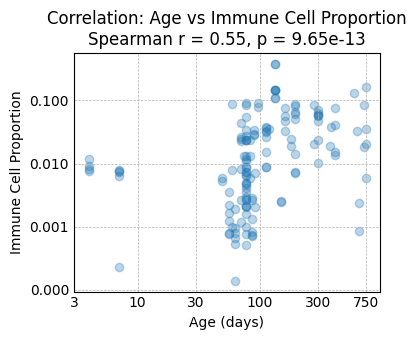

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from matplotlib.ticker import ScalarFormatter

age_numeric = curation["Age_numeric"].values

# change , to .
age_numeric = np.array([str(age).replace(',', '.') for age in age_numeric])
age_numeric = age_numeric.astype(float)

plt.figure(figsize=(4, 3.5))
plt.scatter(age_numeric, immune_cells, alpha=0.3)

corr, p = stats.spearmanr(age_numeric, immune_cells)

plt.title("Correlation: Age vs Immune Cell Proportion\nSpearman r = {:.2f}, p = {:.2e}".format(corr, p))
plt.xlabel("Age (days)")
plt.ylabel("Immune Cell Proportion")

# Log scale
plt.xscale('log')
plt.yscale('log')

# ---- Custom X ticks ----
custom_xticks = [3, 10, 30, 100, 300, 750]
plt.xticks(custom_xticks)

# Force plain number formatting instead of 10^x
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
# Remove minor ticks completely
ax.minorticks_off()

# Grid ONLY for major ticks
ax.grid(True, which='major', linestyle='--', linewidth=0.5)

# Optional: remove tick marks (keep labels)
ax.tick_params(axis='both', which='both', length=0)

plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()

# save
plt.savefig("/Users/k23030440/Library/CloudStorage/OneDrive-King'sCollegeLondon/PhD/Year_two/Aim 1/supplementary/immune_cell_proportion.svg", 
            format='svg', bbox_inches='tight')
plt.savefig("/Users/k23030440/Library/CloudStorage/OneDrive-King'sCollegeLondon/PhD/Year_two/Aim 1/supplementary/immune_cell_proportion.png", 
            format='png', bbox_inches='tight')

plt.show()

In [18]:
#print sample with highest immune cell proportion
max_index = np.argmax(immune_cells)
max_sample = curation.iloc[max_index]
print("Sample with highest immune cell proportion:")
print(max_sample)

Sample with highest immune cell proportion:
GEO                                         GSM8187332
SRA_ID                                     SRX24151434
Name                        HFD_pituitary scRNA-seq_01
Conditions                               high_fat_diet
Normal                                               0
Background                                     C57BL/6
Sorted                                               0
Author                              Qian et al. (2024)
DOI                         10.1016/j.cmet.2024.04.014
Age                                        3+16 weeks?
Sex_numeric                                          1
Sex                                               male
Comp_sex                                           1.0
Estrous_stage                                      NaN
Age_numeric                                        133
Single_pool                                     single
10X version                                      10XV3
Modality             

In [12]:
pip freeze

absl-py==2.1.0
access==1.1.9
adjustText==1.2.0
aext-assistant @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_5blio7a88h/croot/aext-assistant_1717062156186/work
aext-assistant-server @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_84ykzx_q85/croot/aext-assistant-server_1717059976819/work
aext-core @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_6230gwvics/croot/aext-core_1717056412538/work
aext-core-server @ file:///private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_8eywdkec83/croot/aext-core-server_1717075040870/work
aext-panels @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_70wky0p3yf/croot/aext-panels_1717062185397/work
aext-panels-server @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_ce_grc3i0p/croot/aext-panels-server_1717060164537/work
aext-share-notebook @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_72nt4kju8z/croot/aext-share-notebook_